# Municipal Water Utility — Six-Year Financial Plan

A six-year (2025–2030) financial plan for a mid-sized municipal water utility.

Key features demonstrated:
- `FixedLine(value=x)` scalar constants for inflation rate, O&M growth rate, and bond parameters
- `InputLine` for adjustable-default scenario inputs (rate increases, bond rate)
- `FixedLine` schedules for the existing 2015 Series A debt service
- `create_debt_lines` for the 2027 Series B revenue bond ($10M, 4.50%, 20-year)
- Cumulative water rate formula compounding prior-period values
- Recursive cash balance tracking (`starting_cash` / `ending_cash`)
- `FormulaLine` seeds via `values={2025: x}` — no `if t == first_period` guards
- `model.tables.build()` tables for the rate model, cash flow, and debt service schedule

---

**Model scenario (defaults)**

| Parameter | Value |
|-----------|-------|
| Rate increase schedule | 5% / 6% / 5% / 4% / 4% / 3% |
| 2027 Series B par | $10,000,000 |
| Series B rate | 4.5% |
| CPI inflation | 3.0% |
| O&M growth rate | 4.0% |


In [35]:
import sys
from pathlib import Path

_here = Path('.').resolve()
_model_dir = _here if (_here / 'model.py').exists() else _here / 'examples' / 'water_utility'
sys.path.insert(0, str(_model_dir))

from model import PERIODS, WaterUtilityModel, model

## Assumptions

In [36]:
for name in model.line_item_names:
    if name in model._scalars:
        r = model[name]
        print(f"{r.label or name:<42} {r.formatted_value(model.periods[0])}")

CPI Inflation Rate                         3.0%
O&M Growth Rate                            4.0%
Series B Interest Rate                     4.50%
Series B Term (Years)                      20


## Rate Schedule

The water rate compounds from the 2024 actual rate of $4,500/MG.  
Power sales grow at CPI from a 2024 base of $480,000.

In [37]:
from pyproforma import TableDef
from pyproforma.tables import BlankRow, HeaderRow, ItemRow, LabelRow

rate_table = model.tables.build(TableDef(
    title="Rate & Volume Schedule",
    rows=[
        HeaderRow(),
        LabelRow(label="Rate & Volume Inputs"),
        ItemRow(name="rate_increase"),
        ItemRow(name="water_rate"),
        ItemRow(name="mgd_growth_rate"),
        ItemRow(name="mgd"),
    ],
))
rate_table.show()

Fiscal Year,2025,2026,2027,2028,2029,2030
Rate & Volume Inputs,,,,,,
Rate Increase,5.0%,6.0%,5.0%,4.0%,4.0%,3.0%
Water Rate ($/MG),"$4,725","$5,008","$5,259","$5,469","$5,688","$5,859"
MGD Growth Rate,1.0%,1.0%,1.0%,1.0%,1.0%,1.0%
Water Sales (MGD),8.05,8.13,8.21,8.29,8.38,8.46


## Rate Model (Revenue & O&M)

Above-the-line view: revenues vs. O&M, producing Net Revenue available for debt service.

In [38]:
from pyproforma import TableDef
from pyproforma.tables import HeaderRow, ItemRow, LabelRow

rate_model_table = model.tables.build(TableDef(
    title="Rate Model — Revenue & O&M",
    rows=[
        HeaderRow(),
        LabelRow(label="Operating Revenue"),
        ItemRow(name="water_sales_revenue"),
        ItemRow(name="power_sales", bottom_border="single"),
        ItemRow(name="total_revenue", bold=True),
        BlankRow(),
        LabelRow(label="O&M Expenses"),
        ItemRow(name="labor_and_benefits"),
        ItemRow(name="power_and_chemicals"),
        ItemRow(name="maintenance_and_repairs"),
        ItemRow(name="general_and_admin", bottom_border="single"),
        ItemRow(name="total_om", bold=True),
        BlankRow(),
        ItemRow(name="net_revenue", bold=True, top_border="double"),
    ],
))
rate_model_table.show()

Fiscal Year,2025,2026,2027,2028,2029,2030
Operating Revenue,,,,,,
Water Sales Revenue,"$13,883,231","$14,863,387","$15,762,622","$16,557,058","$17,391,534","$18,092,413"
Power Sales,"$494,400","$509,232","$524,509","$540,244","$556,452","$573,145"
Total Revenue,"$14,377,631","$15,372,619","$16,287,131","$17,097,302","$17,947,985","$18,665,558"
,,,,,,
O&M Expenses,,,,,,
Labor & Benefits,"$4,056,000","$4,218,240","$4,386,970","$4,562,448","$4,744,946","$4,934,744"
Power & Chemicals,"$1,751,000","$1,803,530","$1,857,636","$1,913,365","$1,970,766","$2,029,889"
Maintenance & Repairs,"$1,144,000","$1,189,760","$1,237,350","$1,286,844","$1,338,318","$1,391,851"
General & Administrative,"$884,000","$919,360","$956,134","$994,380","$1,034,155","$1,075,521"


## Debt Service Schedule

The 2015 Series A bond ($25M par, 4.25%, 20-year) has ~$17M remaining at BOY 2025.  
The 2027 Series B bond ($10M par, 4.50%, 20-year) is issued in 2027 to fund the transmission main project.

In [39]:
from pyproforma import TableDef

ds_table = model.tables.build(TableDef(
    title="Debt Service Schedule",
    rows=[
        HeaderRow(),
        LabelRow(label="2015 Series A — Existing Bonds"),
        ItemRow(name="existing_principal"),
        ItemRow(name="existing_interest", bottom_border="single"),
        ItemRow(name="total_existing_ds", bold=True),
        BlankRow(),
        LabelRow(label="2027 Series B — New Bond"),
        ItemRow(name="new_bond_par"),
        ItemRow(name="new_bond_principal"),
        ItemRow(name="new_bond_interest", bottom_border="single"),
        ItemRow(name="total_new_ds", bold=True),
        BlankRow(),
        ItemRow(name="total_debt_service", bold=True, top_border="double"),
        BlankRow(),
        LabelRow(label="Principal Outstanding (end of year)"),
        ItemRow(name="existing_outstanding"),
        ItemRow(name="new_bond_outstanding", bottom_border="single"),
        ItemRow(name="total_outstanding", bold=True),
    ],
))
ds_table.show()

Fiscal Year,2025,2026,2027,2028,2029,2030
2015 Series A — Existing Bonds,,,,,,
2015 Series A — Principal,"$1,158,000","$1,207,000","$1,259,000","$1,313,000","$1,369,000","$1,427,000"
2015 Series A — Interest,"$723,000","$674,000","$622,000","$568,000","$512,000","$454,000"
2015 Series A Total DS,"$1,881,000","$1,881,000","$1,881,000","$1,881,000","$1,881,000","$1,881,000"
,,,,,,
2027 Series B — New Bond,,,,,,
New Bond Proceeds,$0,$0,"$10,000,000",$0,$0,$0
2027 Series B — Principal,$0,$0,"$318,761","$333,106","$348,095","$363,760"
2027 Series B — Interest,$0,$0,"$450,000","$435,656","$420,666","$405,002"
2027 Series B Total DS,$0,$0,"$768,761","$768,761","$768,761","$768,761"


## Cash Flow Statement

Below-the-line view: net revenue applied to debt service, capital spending, bond proceeds, and capacity fee contributions.

In [40]:
from pyproforma import TableDef

cf_table = model.tables.build(TableDef(
    title="Cash Flow Statement",
    rows=[
        HeaderRow(),
        ItemRow(name="starting_cash"),
        BlankRow(),
        ItemRow(name="net_revenue", bold=True),
        BlankRow(),
        LabelRow(label="Debt Service"),
        ItemRow(name="total_existing_ds"),
        ItemRow(name="total_new_ds", bottom_border="single"),
        ItemRow(name="total_debt_service", bold=True),
        BlankRow(),
        LabelRow(label="Capital Program"),
        ItemRow(name="capital_spending"),
        ItemRow(name="capacity_fees"),
        ItemRow(name="new_bond_par"),
        BlankRow(),
        ItemRow(name="ending_cash", bold=True, top_border="double"),
    ],
))
cf_table.show()

Fiscal Year,2025,2026,2027,2028,2029,2030
Beginning Cash Balance,"$5,000,000","$6,511,631","$7,822,360","$11,271,639","$12,462,143","$14,222,181"
,,,,,,
Net Revenue,"$6,542,631","$7,241,729","$7,849,041","$8,340,265","$8,859,800","$9,233,553"
,,,,,,
Debt Service,,,,,,
2015 Series A Total DS,"$1,881,000","$1,881,000","$1,881,000","$1,881,000","$1,881,000","$1,881,000"
2027 Series B Total DS,$0,$0,"$768,761","$768,761","$768,761","$768,761"
Total Debt Service,"$1,881,000","$1,881,000","$2,649,761","$2,649,761","$2,649,761","$2,649,761"
,,,,,,
Capital Program,,,,,,


## Key Metrics

| Metric | Definition |
|--------|------------|
| **DSCR** | Net Revenue Ã· Total Debt Service |
| **Days Cash on Hand** | Ending Cash Ã· (Total O&M Ã· 365) |
| **Debt-Funded Capital** | New Bond Principal Ã· Capital Expenditures |

In [41]:
from pyproforma import TableDef

metrics_table = model.tables.build(TableDef(
    title="Key Metrics",
    rows=[
        HeaderRow(),
        ItemRow(name="dscr", bold=True),
        ItemRow(name="days_cash_on_hand", bold=True),
        ItemRow(name="debt_funded_capital", bold=True),
    ],
))
metrics_table.show()

Fiscal Year,2025,2026,2027,2028,2029,2030
Debt Service Coverage Ratio,3.48,3.85,2.96,3.15,3.34,3.48
Days Cash on Hand,303,351,488,519,571,557
Debt-Funded Capital Ratio,0.0%,0.0%,2.7%,6.7%,7.0%,5.2%


## DSCR Analysis

The 2027 Series B bond compresses DSCR from 3.84x (2026) to 2.95x (2027) â€” the model's key stress point.  
Coverage recovers as revenues grow through compounding rate increases.

In [42]:
model.tables.line_item(
    "dscr",
    include_percent_change=True,
).show()

Label,2025,2026,2027,2028,2029,2030
Debt Service Coverage Ratio,3.48,3.85,2.96,3.15,3.34,3.48
Debt Service Coverage Ratio % Change,,10.69%,-23.06%,6.26%,6.23%,4.22%


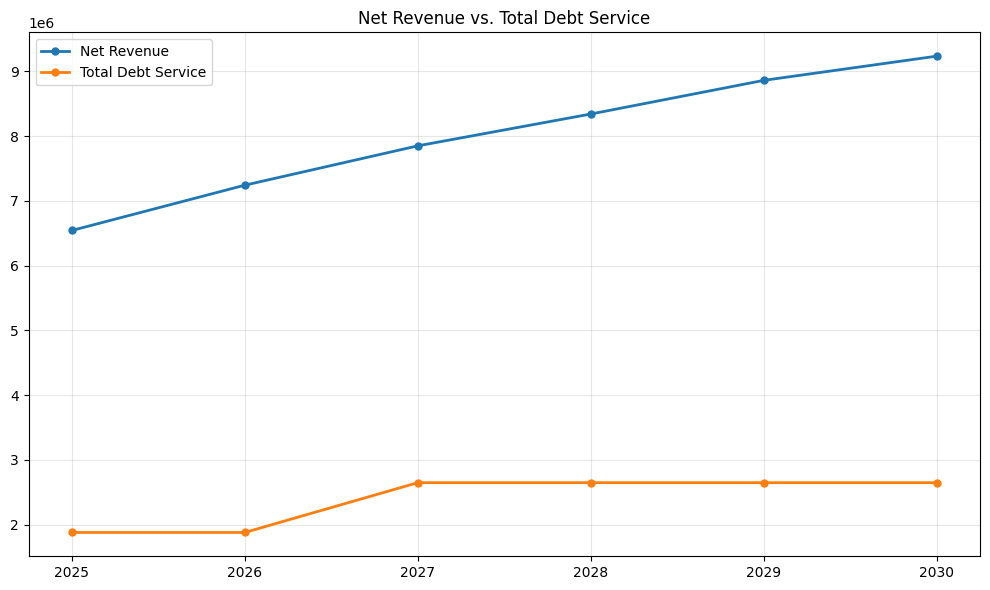

In [43]:
model.charts.line_items(
    ["net_revenue", "total_debt_service"],
    chart_type="line",
    title="Net Revenue vs. Total Debt Service",
).show()

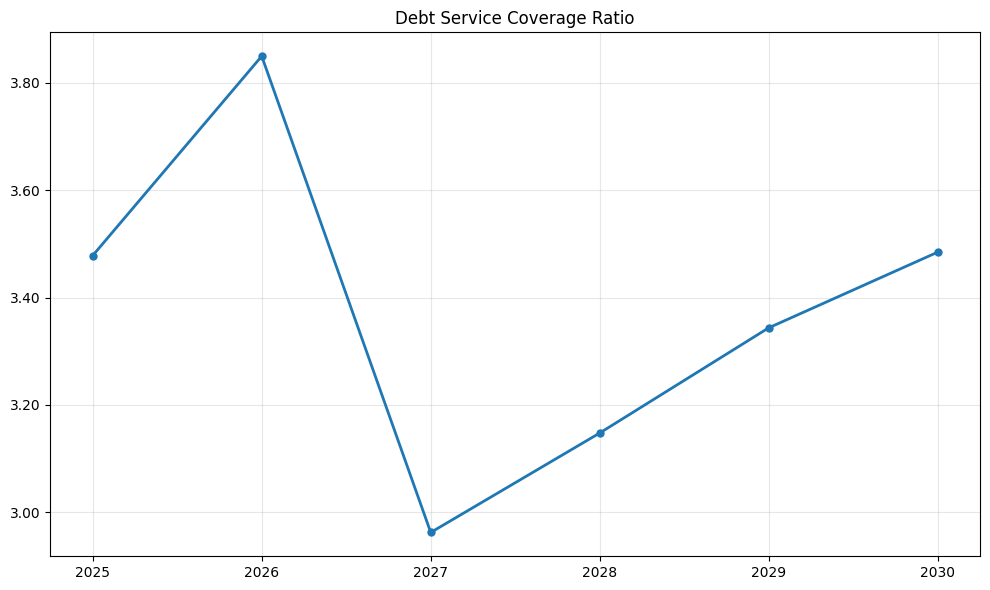

In [44]:
model.charts.line_item(
    "dscr",
    chart_type="line",
    title="Debt Service Coverage Ratio",
).show()

## Revenue Composition

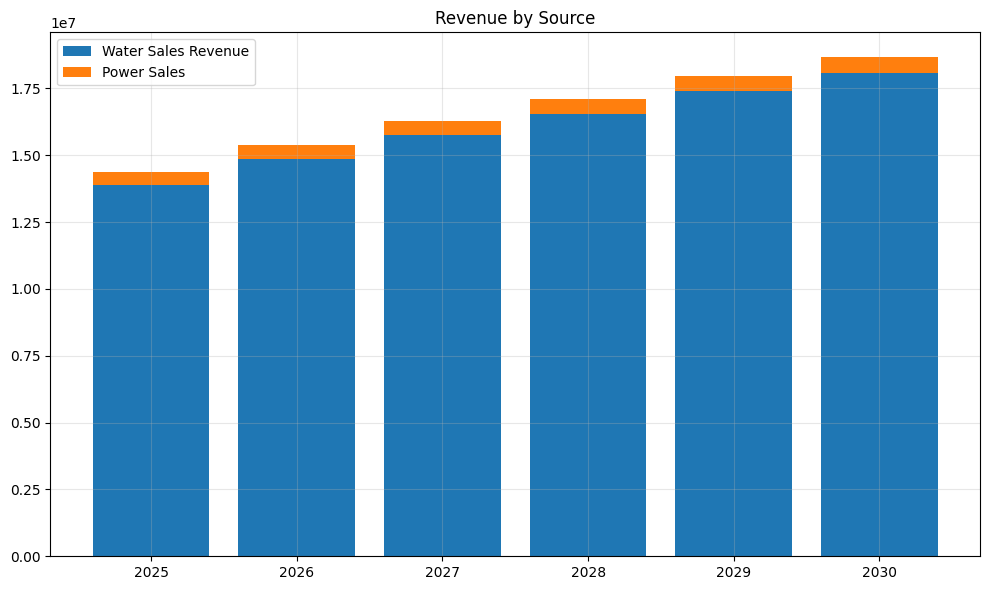

In [45]:
model.charts.line_items(
    ["water_sales_revenue", "power_sales"],
    chart_type="stacked_bar",
    title="Revenue by Source",
).show()

## O&M Expense Composition

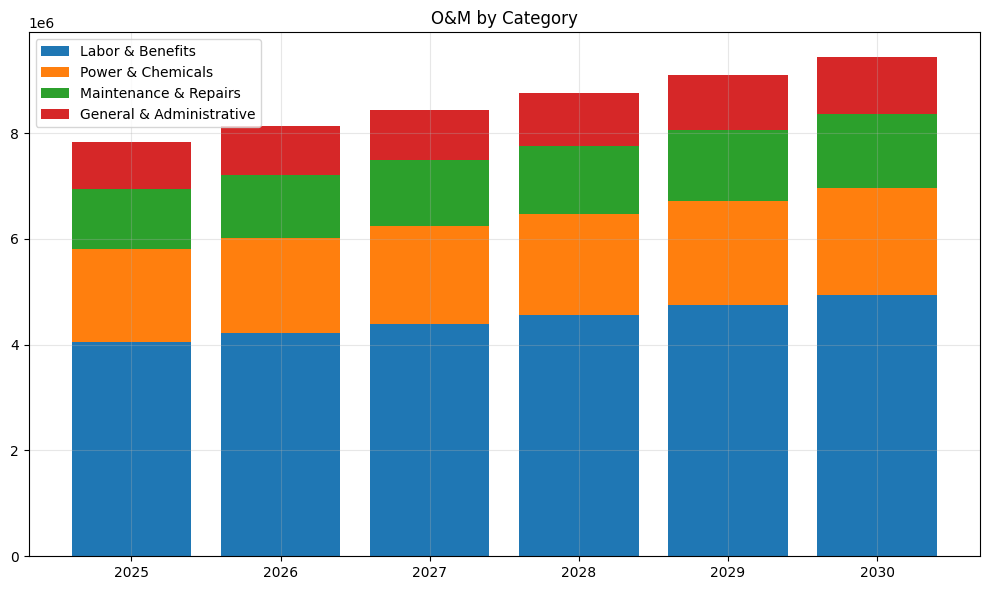

In [46]:
model.charts.line_items(
    ["labor_and_benefits", "power_and_chemicals", "maintenance_and_repairs", "general_and_admin"],
    chart_type="stacked_bar",
    title="O&M by Category",
).show()

## Capital Program and Cash Balance

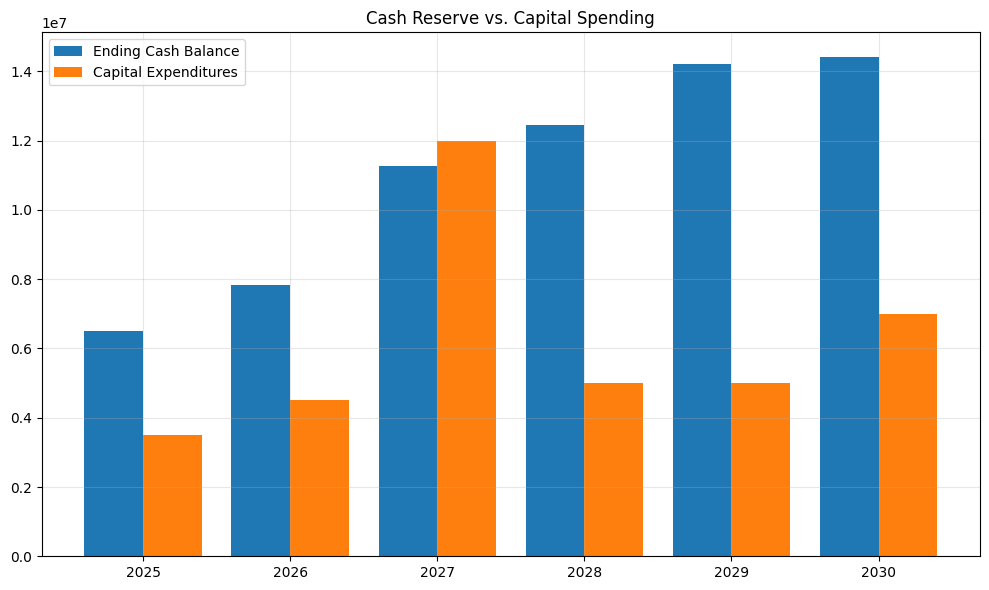

In [47]:
model.charts.line_items(
    ["ending_cash", "capital_spending"],
    chart_type="bar",
    title="Cash Reserve vs. Capital Spending",
).show()

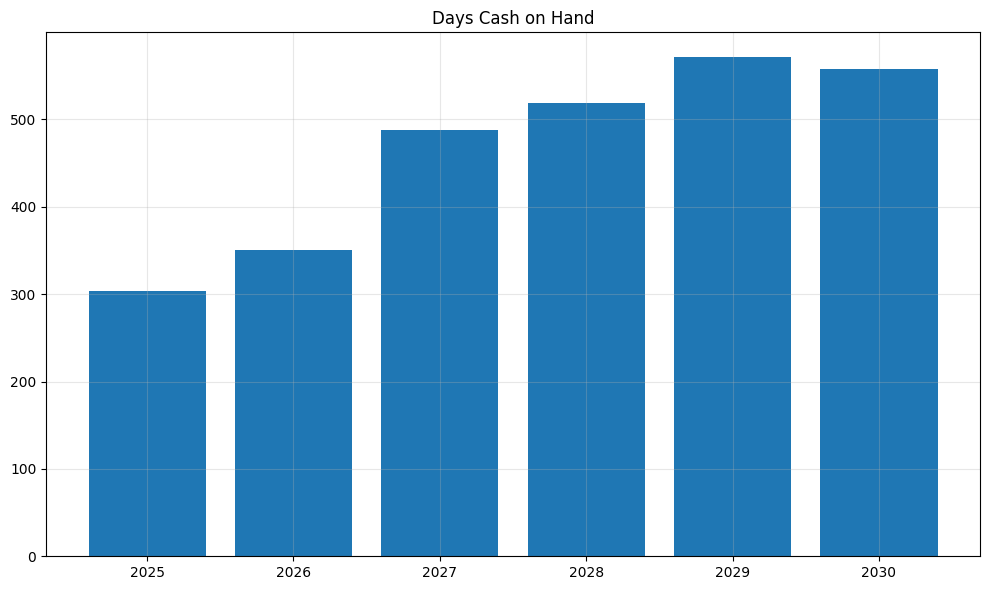

In [48]:
model.charts.line_item(
    "days_cash_on_hand",
    chart_type="bar",
    title="Days Cash on Hand",
).show()

## Principal Outstanding

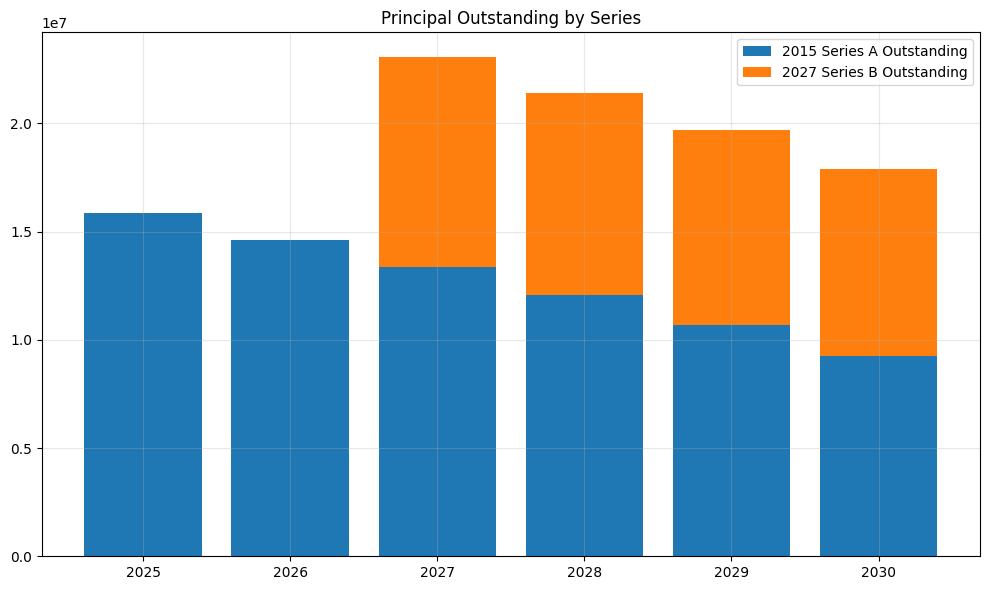

In [49]:
model.charts.line_items(
    ["existing_outstanding", "new_bond_outstanding"],
    chart_type="stacked_bar",
    title="Principal Outstanding by Series",
).show()

## Rate Impact

Compounding rate increases drive the water rate from $4,500/MG in 2024 to over $5,500/MG by 2030.

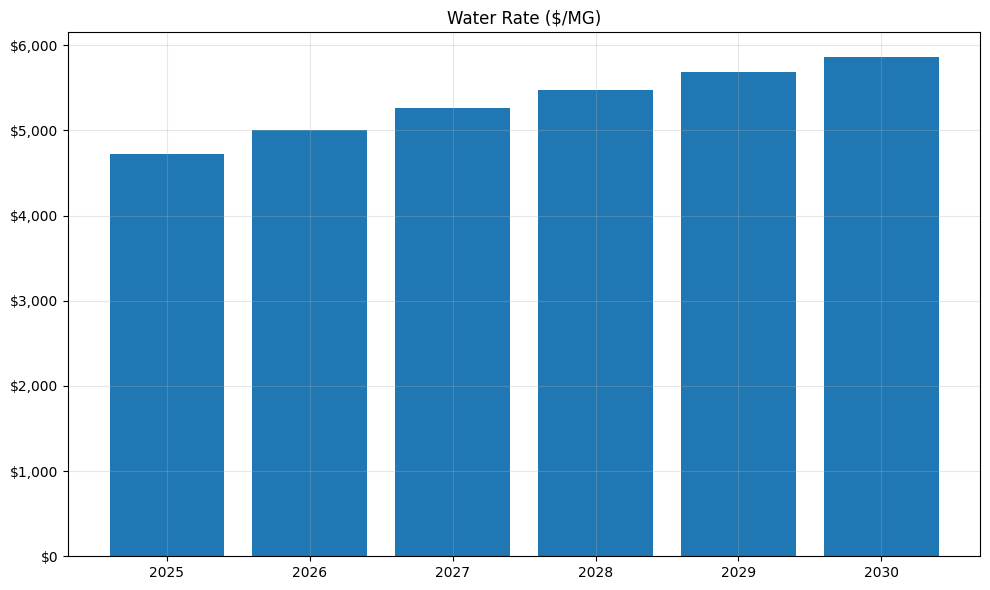

In [50]:
model.charts.line_item(
    "water_rate",
    chart_type="bar",
    title="Water Rate ($/MG)",
).show()

## Scenario: Higher Rate Increases

Pass a custom `rate_increase` dict at instantiation to override the default schedule.
Below, a flat 8% schedule shows the DSCR uplift from more aggressive pricing.

In [51]:
high_rate_model = WaterUtilityModel(
    periods=PERIODS,
    rate_increase={t: 0.08 for t in PERIODS},
)

print("Base vs. high-rate scenario (8% flat) — DSCR comparison:")
print(f"{"Year":<6} {"Base DSCR":>10} {"High-Rate DSCR":>15}")
for t in PERIODS:
    base = model.li.dscr[t]
    high = high_rate_model.li.dscr[t]
    print(f"{t:<6} {base:>10.2f}x {high:>15.2f}x")

Base vs. high-rate scenario (8% flat) — DSCR comparison:
Year    Base DSCR  High-Rate DSCR
2025         3.48x            3.48x
2026         3.85x            4.00x
2027         2.96x            3.25x
2028         3.15x            3.70x
2029         3.34x            4.20x
2030         3.48x            4.75x
